# AI Human Detection Dataset Cleaning

## Objective

This notebook executes the dataset cleaning pipeline.

The cleaning process performs:

- Image validation
- RGB conversion
- JPEG conversion
- Sequential renaming
- Cleaning report generation
- Dataset verification

**Note**

This notebook only executes the pipeline.

All cleaning logic is implemented in `src/cleaning.py`.

In [29]:
from pathlib import Path
import sys
import shutil

PROJECT_ROOT = Path.cwd().parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

In [30]:
import importlib
import src.cleaning

importlib.reload(src.cleaning)

from src.cleaning import DatasetCleaner

In [31]:
from src.cleaning import DatasetCleaner
from src.config import (
    CLEAN_DATASET_DIR,
    METRIC_DIR,
    RAW_DATASET_DIR,
)

## Configuration

In [32]:
SOURCE_DIRECTORY = RAW_DATASET_DIR

DESTINATION_DIRECTORY = CLEAN_DATASET_DIR

REPORT_PATH = (
    METRIC_DIR /
    "cleaning_report.csv"
)

## Execute Cleaning Pipeline

In [33]:
cleaner = DatasetCleaner(
    source_dir=SOURCE_DIRECTORY,
    destination_dir=DESTINATION_DIRECTORY,
)

2026-07-06 20:38:42 | INFO     | Directory ready: C:\Users\HELGA\Documents\AI_Human_Detection\dataset_clean
2026-07-06 20:38:42 | INFO     | ======================================================================
2026-07-06 20:38:42 | INFO     | Dataset Cleaner Initialized
2026-07-06 20:38:42 | INFO     | Source      : C:\Users\HELGA\Documents\AI_Human_Detection\dataset
2026-07-06 20:38:42 | INFO     | Destination : C:\Users\HELGA\Documents\AI_Human_Detection\dataset_clean
2026-07-06 20:38:42 | INFO     | ======================================================================


In [34]:
report = cleaner.run(
    report_path=REPORT_PATH,
    clear_output=True,
)

2026-07-06 20:38:42 | INFO     | 
2026-07-06 20:38:42 | INFO     | ======================================================================
2026-07-06 20:38:42 | INFO     | START CLEANING PIPELINE
2026-07-06 20:38:42 | INFO     | ======================================================================
2026-07-06 20:38:42 | INFO     | 
2026-07-06 20:38:42 | INFO     | ======================================================================
2026-07-06 20:38:42 | INFO     | START DATASET CLEANING
2026-07-06 20:38:42 | INFO     | ======================================================================
2026-07-06 20:38:42 | INFO     | 
2026-07-06 20:38:42 | INFO     | ======================================================================
2026-07-06 20:38:42 | INFO     | Processing class : Authentic
2026-07-06 20:38:42 | INFO     | Images found     : 514
2026-07-06 20:38:42 | INFO     | ======================================================================
 Authentic:   0%|          | 0/514 [00:00<?

## Verification

In [35]:
summary = cleaner.export_summary()

summary

,total_images,processed_images,unreadable_images,failed_images
0,1051,1051,0,0


In [36]:
distribution = cleaner.export_distribution()

distribution

,class,images
0,Authentic,514
1,AI,537


In [37]:
report.head()

,original_filename,new_filename,class_name,status,width,height,format,mode,aspect_ratio,size_kb,md5
0,023d6f6f-06ff-4628-b1f5-b79a616758d5.png,ai_000001.jpg,AI,SUCCESS,886,1775,PNG,RGB,0.499,372.22,a46362a625f2b0d3679faebd47e95fdb
1,02d4a3d4-703d-4668-b606-3599165acda8.png,ai_000002.jpg,AI,SUCCESS,941,1670,PNG,RGB,0.563,251.69,38d1377d0e0820d6d266c50b1eaa3999
2,04e46894-6b2c-4d42-803e-2e08d6341009.png,ai_000003.jpg,AI,SUCCESS,1024,1536,PNG,RGB,0.667,535.76,07dd88d4e6a05910b1e6a9a610d7df64
3,0549007c-7a55-4619-b352-ba7a7d80e3a2.png,ai_000004.jpg,AI,SUCCESS,941,1672,PNG,RGB,0.563,388.06,f69044a74cc388ee1ff8fe2a5a192031
4,07cc5a50-d6fb-4713-ab78-8880291ec844.png,ai_000005.jpg,AI,SUCCESS,853,1844,PNG,RGB,0.463,406.84,63facc662dd78b2db6186eb9e89f9a1e


In [39]:
report.sample(
    min(
        10,
        len(report),
    )
)

,original_filename,new_filename,class_name,status,width,height,format,mode,aspect_ratio,size_kb,md5
243,"ChatGPT Image Jul 2, 2026, 05_11_21 PM.png",ai_000244.jpg,AI,SUCCESS,941,1672,PNG,RGB,0.563,481.71,9bef28bbb9154d3e6934f2644c0ad456
542,01818945e2c06bf1f0bf424702e99913.webp,authentic_000006.jpg,Authentic,SUCCESS,640,427,WEBP,RGB,1.499,130.83,eb587d40f5191a77297b4bfb60ab9af7
623,15361726747_23c865e34e_z.jpg,authentic_000087.jpg,Authentic,SUCCESS,640,426,JPEG,RGB,1.502,85.86,23638a3f155f81a8fd586c2713ff2ebf
1034,wheelchair-access-lift-malaysia-1024x1024.jpg,authentic_000498.jpg,Authentic,SUCCESS,1024,1024,JPEG,RGB,1.000,350.50,b9399c0e6d67375f8b5b0dafa1fbd5a9
1033,WhatsApp Image 2026-07-02 at 21.12.41.jpeg,authentic_000497.jpg,Authentic,SUCCESS,505,476,JPEG,RGB,1.061,34.81,d993f97b8abdd4f810097ee929b77afb
550,036b89de96ab8338.jpg,authentic_000014.jpg,Authentic,SUCCESS,1024,683,JPEG,RGB,1.499,152.79,ec7e01997ce816408ac59eea54e177f9
605,14003246872_70346508ea_z.jpg,authentic_000069.jpg,Authentic,SUCCESS,639,469,JPEG,RGB,1.362,109.85,0d7b1520441497cde2fe747155a178c0
579,1099384864_7823e08bb7_z.jpg,authentic_000043.jpg,Authentic,SUCCESS,639,427,JPEG,RGB,1.496,32.64,4b34712b8253a8deb0b7c0f66897f6c4
174,"ChatGPT Image Jul 2, 2026, 01_41_39 PM.png",ai_000175.jpg,AI,SUCCESS,1448,1086,PNG,RGB,1.333,494.86,040035bd0e04ae028792c73987c44d89
838,677bc5c81e206.jpg,authentic_000302.jpg,Authentic,SUCCESS,1200,800,JPEG,RGB,1.500,237.06,05ab7f4864b50e0ce04f22a885721963


## Visualization

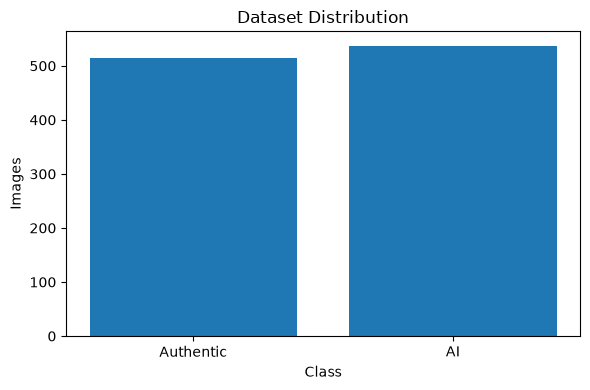

In [38]:
import matplotlib.pyplot as plt

figure = plt.figure(
    figsize=(6, 4),
)

plt.bar(
    distribution["class"],
    distribution["images"],
)

plt.title("Dataset Distribution")

plt.xlabel("Class")

plt.ylabel("Images")

plt.tight_layout()

plt.show()

In [40]:
REPORT_PATH.exists()

True

## Conclusion

The dataset cleaning pipeline successfully:

- validated all readable images,
- converted images into RGB,
- saved all images as JPEG,
- renamed images sequentially,
- generated the cleaning report,
- verified the cleaned dataset.

The cleaned dataset is now ready for preprocessing.